# 01 · Load & QC: building the `AnnData` object (GSE72056)

**Goal (Q2.1).** Turn the messy public `.txt.gz` file into one clean
`AnnData` object that scanpy can work with, then run light quality-control
*checks* (not filtering — the data was already QC'd by the authors).

**What this notebook produces**

| Output | Path |
|---|---|
| Loaded AnnData | `data/processed/tirosh_anndata_raw.h5ad` |
| QC violin plots | `results/figures/01_*.png` |
| Answers to 3 questions | final cell of this notebook |

**Recap from `00_data_exploration.ipynb`** — already established there:

- The file is `genes × cells` (must be **transposed** for scanpy).
- The first 3 data rows are per-cell metadata, not genes.
- Values are **`log2(TPM/10 + 1)`** — *already normalized and
  log-transformed*. We therefore **never** call
  `sc.pp.normalize_total()` or `sc.pp.log1p()` on this matrix.

> **What is `AnnData`?** A "data + annotations" container. `adata.X` holds
> the `cells × genes` expression matrix; `adata.obs` annotates each cell
> (patient, malignancy, cell type, later: clusters); `adata.var` annotates
> each gene; `adata.obsm` holds embeddings (PCA/UMAP/scVI later); `adata.layers`
> holds alternative same-shape matrices. Every scanpy function takes `adata`
> and adds to it: `sc.xx.yy(adata, ...)`.

## Step 0 — Imports, paths, environment

`scanpy` (`sc`) is the analysis toolkit; `anndata` (`ad`) builds the
container. Paths are resolved so the notebook runs whether launched from
`notebooks/` or the repo root.

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import date
from importlib.metadata import version

%matplotlib inline
sc.settings.verbosity = 1

def _resolve(*candidates):
    """Return the first path whose parent (or itself) exists."""
    for c in candidates:
        p = Path(c)
        if p.exists() or p.parent.exists():
            return p
    return Path(candidates[0])

RAW = _resolve("../data/raw/GSE72056_melanoma_single_cell_revised_v2.txt.gz",
               "data/raw/GSE72056_melanoma_single_cell_revised_v2.txt.gz")
PROC   = _resolve("../data/processed", "data/processed")
FIGDIR = _resolve("../results/figures", "results/figures")
PROC.mkdir(parents=True, exist_ok=True)
FIGDIR.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = FIGDIR

assert RAW.exists(), f"Raw data not found: {RAW.resolve()}"
print("scanpy", version("scanpy"), "| anndata", version("anndata"),
      "| pandas", version("pandas"), "| numpy", version("numpy"))
print("raw   :", RAW.resolve())
print("proc  :", PROC.resolve())
print("figdir:", FIGDIR.resolve())

scanpy 1.11.5 | anndata 0.12.14 | pandas 2.3.3 | numpy 2.4.5
raw   : /Users/youyouwu/Desktop/melanoma-scrnaseq-reanalysis/data/raw/GSE72056_melanoma_single_cell_revised_v2.txt.gz
proc  : /Users/youyouwu/Desktop/melanoma-scrnaseq-reanalysis/data/processed
figdir: /Users/youyouwu/Desktop/melanoma-scrnaseq-reanalysis/results/figures


## Step 1 — Load the raw matrix

`index_col=0` makes the first column (gene / metadata labels) the row index,
so every remaining column is exactly one single cell. pandas decompresses
`.gz` transparently. Loading takes ~10–15 s.

In [2]:
df = pd.read_csv(RAW, sep="\t", index_col=0)
print("Loaded:", df.shape, " (rows = 3 metadata + genes, cols = cells)")
print("First 3 row labels:", list(df.index[:3]))
print("First 2 cell IDs  :", list(df.columns[:2]))

Loaded: (23689, 4645)  (rows = 3 metadata + genes, cols = cells)
First 3 row labels: ['tumor', 'malignant(1=no,2=yes,0=unresolved)', 'non-malignant cell type (1=T,2=B,3=Macro.4=Endo.,5=CAF;6=NK)']
First 2 cell IDs  : ['Cy72_CD45_H02_S758_comb', 'CY58_1_CD45_B02_S974_comb']


## Step 2 — Split metadata from the expression matrix

The first 3 rows describe each cell; the rest are genes.

| Row label | Field | Codes |
|---|---|---|
| `tumor` | patient / tumor of origin | integer ID |
| `malignant(1=no,2=yes,0=unresolved)` | malignancy call | 0/1/2 |
| `non-malignant cell type (...)` | cell-type code | 0=n/a,1=T,2=B,3=Macro,4=Endo,5=CAF,6=NK |

In [3]:
meta = df.iloc[:3]     # 3 per-cell metadata rows
expr = df.iloc[3:]     # gene expression: genes x cells

print("metadata  :", meta.shape, "->", meta.shape[1], "cells x", meta.shape[0], "fields")
print("expression:", expr.shape, "->", expr.shape[0], "genes x", expr.shape[1], "cells")
print("metadata row labels:")
for r in meta.index:
    print("  -", r)

metadata  : (3, 4645) -> 4645 cells x 3 fields
expression: (23686, 4645) -> 23686 genes x 4645 cells
metadata row labels:
  - tumor
  - malignant(1=no,2=yes,0=unresolved)
  - non-malignant cell type (1=T,2=B,3=Macro.4=Endo.,5=CAF;6=NK)


## Step 3 — Build the per-cell annotation table (`obs`)

We transpose the 3 metadata rows into a `cells × fields` table, give the
columns short names, cast the codes to integers, and attach human-readable
labels. `patient` is created as a categorical column now because it will be
the **batch key** for scVI/scANVI in Stage 3.

In [4]:
obs = meta.T.copy()
obs.columns = ["tumor_id", "malignant_status", "cell_type_code"]
obs = obs.astype({"tumor_id": "int64",
                  "malignant_status": "int64",
                  "cell_type_code": "int64"})
obs.index.name = "cell_id"

MAL = {0: "unresolved", 1: "non-malignant", 2: "malignant"}
CT  = {0: "n/a (malignant/unresolved)", 1: "T", 2: "B", 3: "Macrophage",
       4: "Endothelial", 5: "CAF", 6: "NK"}
obs["malignant_label"] = obs["malignant_status"].map(MAL).astype("category")
obs["cell_type_label"] = obs["cell_type_code"].map(CT).astype("category")
obs["patient"]         = obs["tumor_id"].astype("category")

obs.head()

,tumor_id,malignant_status,cell_type_code,malignant_label,cell_type_label,patient
cell_id,,,,,,
Cy72_CD45_H02_S758_comb,72,1,2,non-malignant,B,72
CY58_1_CD45_B02_S974_comb,58,1,1,non-malignant,T,58
Cy71_CD45_D08_S524_comb,71,2,0,malignant,n/a (malignant/unresolved),71
Cy81_FNA_CD45_B01_S301_comb,81,2,0,malignant,n/a (malignant/unresolved),81
Cy80_II_CD45_B07_S883_comb,80,2,0,malignant,n/a (malignant/unresolved),80


## Step 4 — Assemble the `AnnData` object

Three things matter here:

1. **Transpose.** The file is `genes × cells`; scanpy wants `cells × genes`.
2. **`float32`.** Halves memory for the 4,645 × 23,686 matrix; precision is
   ample for `log2(TPM/10+1)` values.
3. **Unique gene names.** Symbols like `MARCH1`/`MARCH2` appear twice in the
   file; AnnData requires unique `var_names`, so we disambiguate them
   (`MARCH1`, `MARCH1-1`) *before* constructing the object.

We deliberately do **no** normalization or log transform — the matrix is
already `log2(TPM/10+1)`. This is recorded in `adata.uns["provenance"]`.

In [5]:
from anndata.utils import make_index_unique

# Disambiguate duplicate gene symbols *before* building AnnData (avoids the
# "names are not unique" warning). Same algorithm as var_names_make_unique:
# MARCH1, MARCH1 -> MARCH1, MARCH1-1
genes = pd.Index(expr.index, name="gene")
n_dup = int(genes.duplicated().sum())
genes = make_index_unique(genes)

X   = np.ascontiguousarray(expr.to_numpy(dtype=np.float32).T)  # cells x genes
var = pd.DataFrame(index=genes)
obs = obs.loc[expr.columns]            # align obs to X's cell order

adata = ad.AnnData(X=X, obs=obs, var=var)
print(f"Duplicate gene symbols disambiguated: {n_dup}")

adata.uns["provenance"] = {
    "source_file": RAW.name,
    "geo_accession": "GSE72056",
    "paper": "Tirosh et al., Science 2016",
    "value_type": "log2(TPM/10 + 1) -- already normalized & log-transformed",
    "normalization_applied_here": "NONE (intentional)",
    "built": str(date.today()),
}
adata

Duplicate gene symbols disambiguated: 2


AnnData object with n_obs × n_vars = 4645 × 23686
    obs: 'tumor_id', 'malignant_status', 'cell_type_code', 'malignant_label', 'cell_type_label', 'patient'
    uns: 'provenance'

## Step 5 — Composition sanity check  *(Question 2)*

How many malignant vs. non-malignant cells, and which cell types dominate?
These numbers should match `00_data_exploration.ipynb`
(non-malignant ≈ 3256, malignant ≈ 1257, unresolved ≈ 132).

In [6]:
print("Malignancy call:")
print(adata.obs["malignant_label"].value_counts())
print("\nNon-malignant cell types (code 0 = malignant/unresolved):")
print(adata.obs["cell_type_label"].value_counts())

Malignancy call:
malignant_label
non-malignant    3256
malignant        1257
unresolved        132
Name: count, dtype: int64

Non-malignant cell types (code 0 = malignant/unresolved):
cell_type_label
T                             2068
n/a (malignant/unresolved)    1758
B                              515
Macrophage                     126
Endothelial                     65
CAF                             61
NK                              52
Name: count, dtype: int64


## Step 6 — Basic QC metrics

`sc.pp.calculate_qc_metrics` adds per-cell `n_genes_by_counts` and
`total_counts` to `adata.obs`.

> ⚠️ **Naming caveat.** scanpy was built for UMI count data, so it calls
> these "counts". Our matrix is `log2(TPM/10+1)`, **not** counts. Therefore:
> - `n_genes_by_counts` = number of genes with a **non-zero** value per cell
>   → still meaningful (genes *detected*).
> - `total_counts` = the **sum of log-expression values** per cell → a rough
>   proxy for overall expression, **not** a read/UMI total. Interpret with
>   care; we use it only as a relative health indicator.
>
> We do **not** filter any cells — Tirosh et al. already applied QC. This is
> inspection only, hence the saved file is named `..._raw.h5ad`.

In [7]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
print(adata.obs[["n_genes_by_counts", "total_counts"]].describe().round(2))

       n_genes_by_counts  total_counts
count            4645.00       4645.00
mean             4427.22      11000.88
std              1710.38       2962.87
min              1370.00       2595.13
25%              3146.00       8865.80
50%              4058.00      10422.70
75%              5368.00      12802.04
max             13276.00      23502.75


## Step 7 — QC distribution plots  *(Question 1)*

- **(a)** overall distributions of genes-detected and total-expression;
- **(b)** genes-detected split by patient (first look at batch heterogeneity);
- **(c)** number of cells per patient.

Smart-seq2 typically detects ~1,000–8,000 genes per cell — we expect the
violin to sit in that range.

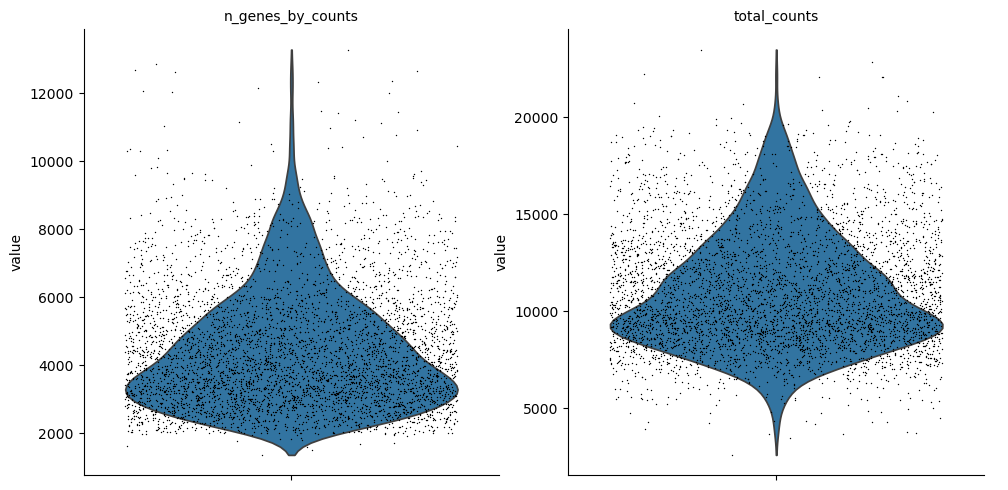

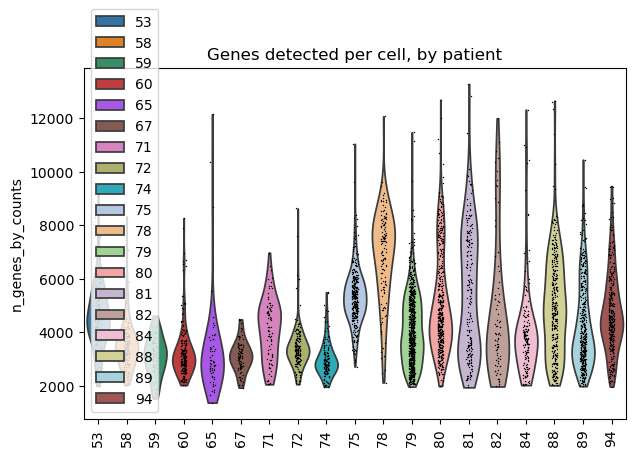

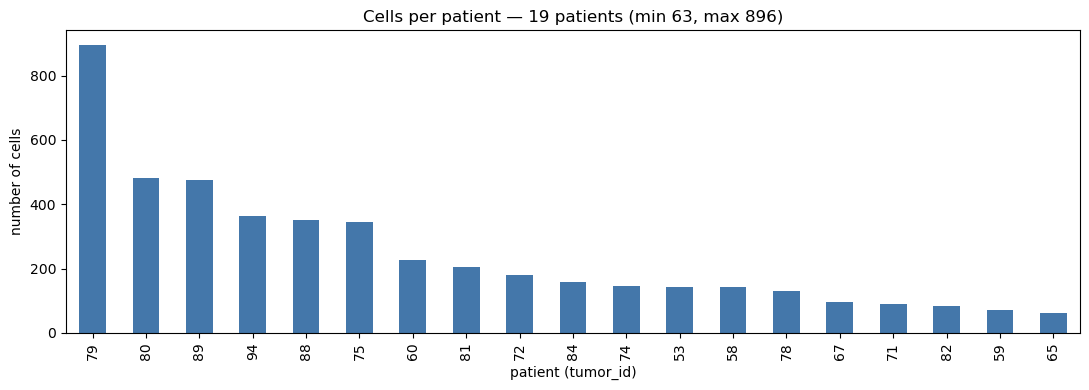

In [8]:
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts"],
             jitter=0.4, multi_panel=True, show=False)
plt.savefig(FIGDIR / "01_qc_violin_overall.png", dpi=150, bbox_inches="tight")
plt.show()

sc.pl.violin(adata, "n_genes_by_counts", groupby="patient",
             rotation=90, show=False)
plt.title("Genes detected per cell, by patient")
plt.savefig(FIGDIR / "01_qc_genes_by_patient.png", dpi=150, bbox_inches="tight")
plt.show()

counts = adata.obs["patient"].value_counts().sort_values(ascending=False)
ax = counts.plot(kind="bar", figsize=(11, 4), color="#4477aa")
ax.set_xlabel("patient (tumor_id)"); ax.set_ylabel("number of cells")
ax.set_title(f"Cells per patient — {counts.size} patients "
             f"(min {counts.min()}, max {counts.max()})")
plt.tight_layout()
plt.savefig(FIGDIR / "01_cells_per_patient.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8 — Per-patient composition  *(Question 3 — important)*

This directly informs the **batch-effect strategy in Stage 3**. Patient
sample sizes are very uneven, and the malignant/non-malignant mix differs by
patient, so "patient" is confounded with biology — exactly why deep-learning
integration (scVI/scANVI with `batch_key="patient"`) is motivated here.

In [9]:
counts = adata.obs["patient"].value_counts()
print(f"Patients               : {counts.size}")
print(f"Largest  : patient {counts.idxmax()} -> {counts.max()} cells")
print(f"Smallest : patient {counts.idxmin()} -> {counts.min()} cells")
print(f"Median cells / patient : {int(counts.median())}")
print(f"Imbalance (max / min)  : {counts.max() / counts.min():.1f}x")
print()
mix = (adata.obs.groupby("patient", observed=True)["malignant_label"]
       .value_counts().unstack(fill_value=0))
print(mix)

Patients               : 19
Largest  : patient 79 -> 896 cells
Smallest : patient 65 -> 63 cells
Median cells / patient : 159
Imbalance (max / min)  : 14.2x

malignant_label  malignant  non-malignant  unresolved
patient                                              
53                      16            124           3
58                       0            141           1
59                      54             12           4
60                       9            213           4
65                       4             55           4
67                       0             95           0
71                      54             30           5
72                       0            181           0
74                       0            147           0
75                       3            340           1
78                     120              3           8
79                     468            393          35
80                     125            344          11
81                     133      

## Step 9 — Save the AnnData object

Persist to `data/processed/tirosh_anndata_raw.h5ad` and reload it to confirm
the file round-trips cleanly.

In [10]:
out = PROC / "tirosh_anndata_raw.h5ad"
adata.write_h5ad(out)
print(f"Saved: {out.resolve()}  ({out.stat().st_size / 1e6:.1f} MB)")

chk = sc.read_h5ad(out)
assert chk.shape == adata.shape, "shape mismatch on reload"
assert list(chk.obs.columns) == list(adata.obs.columns), "obs columns mismatch"
print("Reload OK:", chk.shape, "| obs:", list(chk.obs.columns))

Saved: /Users/youyouwu/Desktop/melanoma-scrnaseq-reanalysis/data/processed/tirosh_anndata_raw.h5ad  (442.2 MB)


Reload OK: (4645, 23686) | obs: ['tumor_id', 'malignant_status', 'cell_type_code', 'malignant_label', 'cell_type_label', 'patient', 'n_genes_by_counts', 'total_counts']


## Conclusions — answers to the three questions

1. **Is the data healthy?** Genes detected per cell sits squarely in the
   Smart-seq2 range (~1k–8k), with no degenerate near-zero population →
   the (already author-QC'd) data is healthy.
2. **Malignant vs non-malignant?** **Non-malignant cells are the majority**
   (~3,256 vs ~1,257; plus ~132 unresolved). The CD45+ FACS sorting in the
   original study enriched immune cells, which is why non-malignant dominates.
3. **Per-patient distribution & implication?** ~19 patients with a **large
   imbalance** between the biggest and smallest patient, and patient-specific
   malignant/non-malignant mixes. Patient is therefore confounded with
   biological signal. **Implication for Stage 3:** patient must be treated as
   the batch covariate (`batch_key="patient"` in scVI/scANVI); naïve PCA/UMAP
   risks clustering by patient rather than by cell state — this is the core
   motivation for the deep-learning integration step.

The exact numbers are printed below.

In [11]:
nm = adata.obs["malignant_label"].value_counts()
pc = adata.obs["patient"].value_counts()
g  = adata.obs["n_genes_by_counts"]

print("=" * 60)
print("Q2.1 — ANSWERS (numbers from this run)")
print("=" * 60)
print(f"\n[1] Genes detected / cell: median {int(g.median())}, "
      f"IQR {int(g.quantile(.25))}-{int(g.quantile(.75))}, "
      f"range {int(g.min())}-{int(g.max())}  -> healthy Smart-seq2")
print(f"\n[2] Malignancy:")
for k, v in nm.items():
    print(f"      {k:<14} {v}")
print(f"    -> non-malignant majority "
      f"({nm.get('non-malignant', 0)} vs {nm.get('malignant', 0)})")
print(f"\n[3] Patients: {pc.size} | "
      f"largest {pc.idxmax()}={pc.max()} | smallest {pc.idxmin()}={pc.min()} | "
      f"imbalance {pc.max()/pc.min():.0f}x")
print(f"    -> use batch_key='patient' for scVI/scANVI in Stage 3")

Q2.1 — ANSWERS (numbers from this run)

[1] Genes detected / cell: median 4058, IQR 3146-5368, range 1370-13276  -> healthy Smart-seq2

[2] Malignancy:
      non-malignant  3256
      malignant      1257
      unresolved     132
    -> non-malignant majority (3256 vs 1257)

[3] Patients: 19 | largest 79=896 | smallest 65=63 | imbalance 14x
    -> use batch_key='patient' for scVI/scANVI in Stage 3
